In [1]:
#Here are all the libraries I'll need for this assessment

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor

In [2]:
#I want to first read and inspect the dataset

data = pd.read_csv("GlobalWeatherRepository.csv")
data.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147930 entries, 0 to 147929
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       147930 non-null  object 
 1   location_name                 147930 non-null  object 
 2   latitude                      147930 non-null  float64
 3   longitude                     147930 non-null  float64
 4   timezone                      147930 non-null  object 
 5   last_updated_epoch            147930 non-null  int64  
 6   last_updated                  147930 non-null  object 
 7   temperature_celsius           147930 non-null  float64
 8   temperature_fahrenheit        147930 non-null  float64
 9   condition_text                147930 non-null  object 
 10  wind_mph                      147930 non-null  float64
 11  wind_kph                      147930 non-null  float64
 12  wind_degree                   147930 non-nul

In [4]:
data.describe()

,latitude,longitude,last_updated_epoch,temperature_celsius,temperature_fahrenheit,wind_mph,wind_kph,wind_degree,pressure_mb,pressure_in,...,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,moon_illumination
count,147930.000000,147930.000000,1.479300e+05,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,...,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000,147930.000000
mean,19.228536,21.909049,1.748772e+09,21.285063,70.314896,7.959010,12.812560,169.253072,1014.054546,29.944443,...,18.130174,442.495100,57.602684,14.625611,10.001743,23.606273,47.374636,1.677915,2.556236,49.824430
std,24.406777,65.780790,1.900548e+07,9.559345,17.206690,7.057586,11.354667,103.547424,10.063273,0.297117,...,13.594301,733.826634,30.568493,23.090161,34.306763,35.899508,146.073160,0.929492,2.410225,35.117941
min,-41.300000,-175.200000,1.715849e+09,-29.800000,-21.600000,2.200000,3.600000,1.000000,947.000000,27.960000,...,3.600000,-9999.000000,0.000000,0.000000,-9999.000000,0.168000,-1848.150000,1.000000,1.000000,0.000000
25%,4.050300,-6.836100,1.732352e+09,15.900000,60.700000,3.800000,6.100000,80.000000,1010.000000,29.830000,...,10.100000,190.550000,38.000000,1.778000,1.110000,6.950000,9.750000,1.000000,1.000000,15.000000
50%,17.250000,23.236100,1.748768e+09,23.600000,74.500000,6.700000,10.800000,162.000000,1013.000000,29.930000,...,15.200000,283.050000,54.400000,5.650000,2.405000,13.750000,19.400000,1.000000,2.000000,50.000000
75%,40.400000,49.882200,1.765178e+09,27.900000,82.200000,11.000000,17.600000,256.000000,1018.000000,30.060000,...,24.100000,444.000000,73.000000,16.800000,7.955000,27.010000,40.515000,2.000000,3.000000,85.000000
max,65.300000,179.220000,1.781677e+09,79.300000,174.700000,1841.200000,2963.200000,360.000000,3006.000000,88.770000,...,2970.400000,38879.398000,480.700000,427.700000,521.330000,1614.100000,6037.290000,6.000000,10.000000,100.000000


In [5]:
data.isnull().sum()

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [6]:
# While inspecting the data, I noticed that the type of last_updated is an object, which is incorrect. 
#I shall convert it to datetime.

data['last_updated'] = pd.to_datetime(data['last_updated'])
print(data['last_updated'].dtype)

datetime64[ns]


In [7]:
#I also noticed a little issue(outliers) with the temperature columns (temperature_celsius & temperature_fahrenheit). 
#I ought to clean and correct those outliers...

data_cleaned = data[(data["temperature_celsius"] >= -50) & (data["temperature_celsius"] <= 50)].copy()

Text(0.5, 0, 'Date')

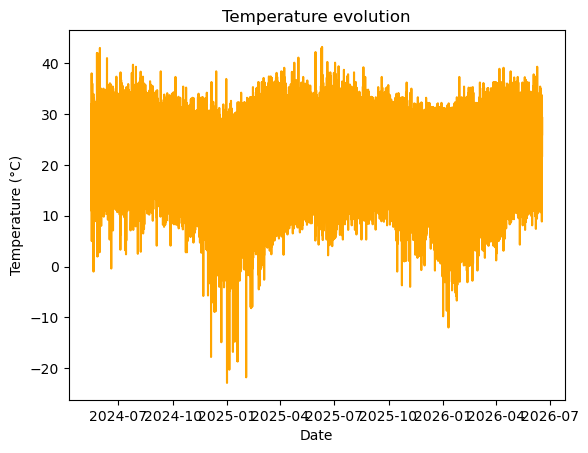

In [8]:
#EDA, let's visualize the temperature evolution
#and the global distribution

data_trend = (data_cleaned.groupby("last_updated")["temperature_celsius"].mean()).to_frame()

plt.plot( data_trend.index, data_trend, color = "orange")
plt.title("Temperature evolution")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")

Text(0.5, 1.0, 'Global Precipitation Distribution (Log Scale)')

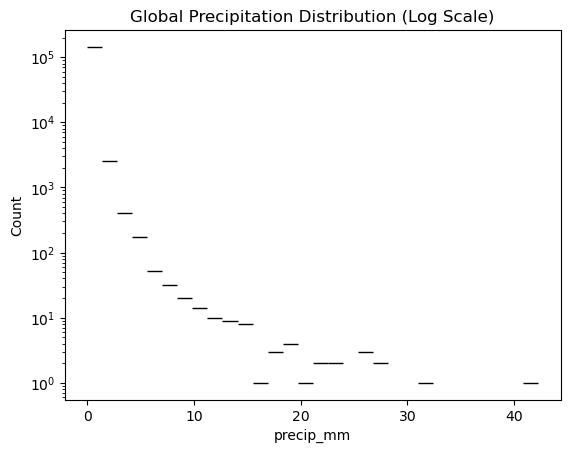

In [9]:
sns.histplot(data = data_cleaned, x='precip_mm', bins = 30,log_scale=(False, True))
plt.title("Global Precipitation Distribution (Log Scale)")

In [10]:
# Chronological split to prevent data leakage in time series

data_train = data_trend[data_trend.index < "2026-01-01"].copy()
data_test = data_trend[data_trend.index >= "2026-01-01"].copy()

data_train["temp_yesterday"] = data_train["temperature_celsius"].shift(1)
data_train_clean = data_train.dropna(subset=["temp_yesterday"]).copy()

X_train = data_train_clean[["temp_yesterday"]]
y_train = data_train_clean["temperature_celsius"]

In [11]:
data_test["temp_yesterday"] = data_test["temperature_celsius"].shift(1)
data_test_clean = data_test.dropna(subset=["temp_yesterday"]).copy()

X_test = data_test_clean[["temp_yesterday"]]
y_test = data_test_clean["temperature_celsius"]

In [12]:
#Model training and prediction

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

In [13]:
# Evaluating model performance using MAE and RMSE metrics

print("The mean absolute error", mean_absolute_error(y_test, pred))
print("The root mean squared error", np.sqrt(mean_squared_error(y_test, pred)))

The mean absolute error 5.173515342105876
The root mean squared error 6.983754227607192


In [14]:
#Let's calculate the security bounderies

Q1 = data['temperature_celsius'].quantile(0.25)
Q3 = data['temperature_celsius'].quantile(0.75)

IQR = Q3 - Q1

inferior_bound = Q1 - 1.5 * IQR
superior_bound = Q3 + 1.5 * IQR

print(f"Normal temperature zone : de {inferior_bound:.2f}°C à {superior_bound:.2f}°C")

Normal temperature zone : de -2.10°C à 45.90°C


In [15]:
#anomalies 

anomalies = data[(data['temperature_celsius'] < inferior_bound) | (data['temperature_celsius'] > superior_bound)]

print(f"Number of detected anomalies : {len(anomalies)}")

Number of detected anomalies : 2459


In [16]:
#Correlation matrix

colonnes_environnement = [
    'temperature_celsius', 
    'precip_mm', 
    'air_quality_Ozone', 
    'air_quality_Carbon_Monoxide', 
    'air_quality_PM2.5', 
    'air_quality_PM10'
]
matrice_corr = data_cleaned[colonnes_environnement].corr()

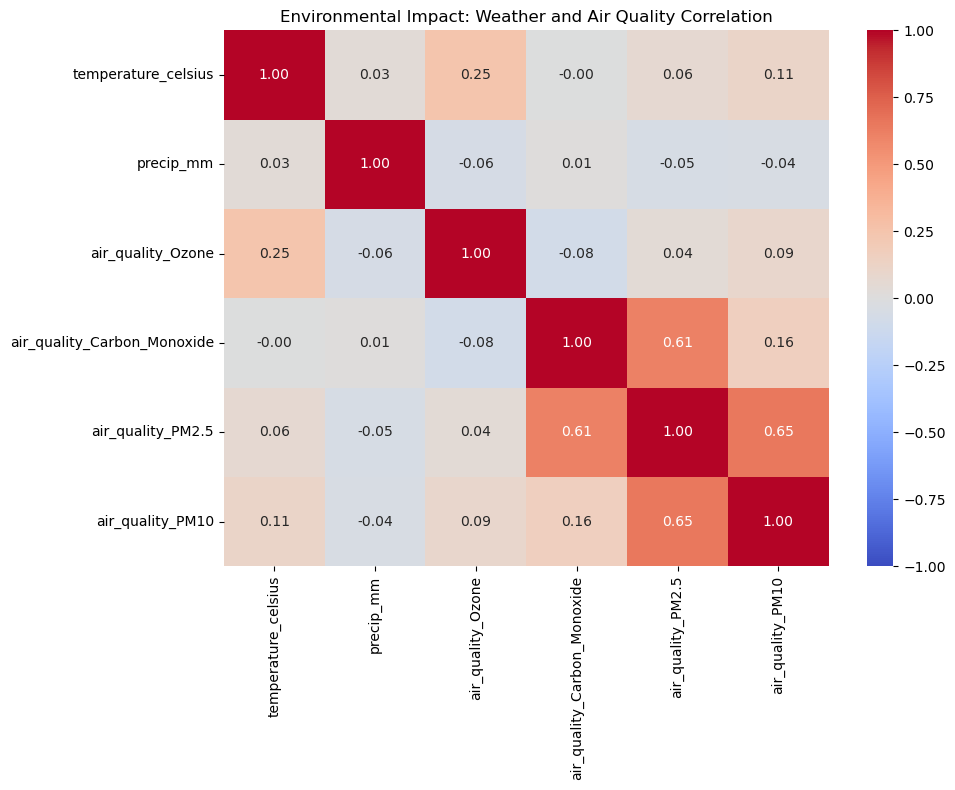

In [17]:
#Environmental Impact: Weather and Air Quality Correlation

plt.figure(figsize=(10, 8))
sns.heatmap(matrice_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title("Environmental Impact: Weather and Air Quality Correlation")
plt.tight_layout()
plt.show()

In [18]:
#the top 10 hottest countries

top_10_hot_countries = (data_cleaned.groupby("country")["temperature_celsius"].mean().sort_values(ascending=False).head(10))

C:\Users\DELL\AppData\Local\Temp\ipykernel_15216\608684987.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_hot_countries.values, y=top_10_hot_countries.index, palette="Reds_r")


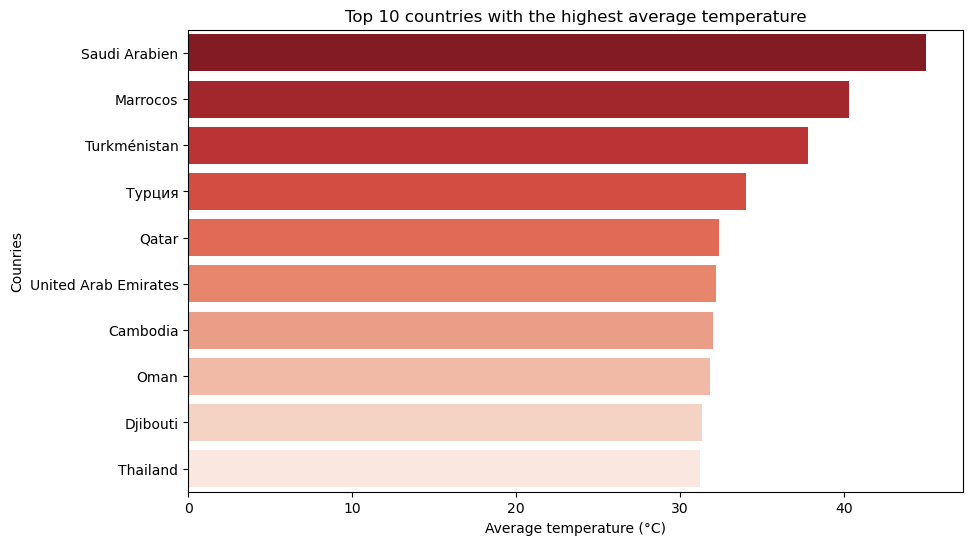

In [19]:
# Plotting the top 10 hottest countries using a horizontal bar plot


plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_hot_countries.values, y=top_10_hot_countries.index, palette="Reds_r")

plt.title("Top 10 countries with the highest average temperature")
plt.xlabel("Average temperature (°C)")
plt.ylabel("Counries")

plt.show()

In [20]:
#Extracting features and target variable to analyze feature importance

X_importance = data_cleaned[["wind_kph", "humidity", "cloud", "pressure_mb"]]

y_importance = data_cleaned["feels_like_celsius"]

In [21]:
#Decision trees training

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_importance, y_importance)

DecisionTreeRegressor(random_state=42)

In [22]:
#Serie creation

importances = dt_model.feature_importances_

feature_imp_series = pd.Series(importances, index=X_importance.columns).sort_values(ascending=False)

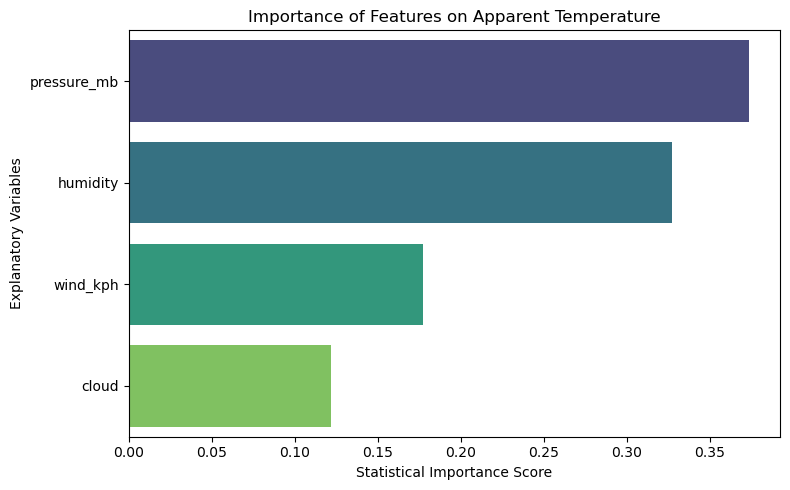

In [23]:
#Barplot

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_imp_series.values, y=feature_imp_series.index, hue=feature_imp_series.index, palette="viridis", legend=False)

plt.title("Importance of Features on Apparent Temperature")
plt.xlabel("Statistical Importance Score")
plt.ylabel("Explanatory Variables")
plt.tight_layout()
plt.show()

In [24]:
#Forecasting with Multiple Models

dt_forecast = DecisionTreeRegressor(max_depth=5, random_state=42)

dt_forecast.fit(X_train, y_train)

pred_dt = dt_forecast.predict(X_test)

In [25]:
pred_ensemble = (pred + pred_dt) / 2

mae_ensemble = mean_absolute_error(y_test, pred_ensemble)
print(f"MAE de l'Ensemble : {mae_ensemble:.2f}°C")

MAE de l'Ensemble : 5.08°C
